# Laboratorio 6 — Reconstrucción LAB5: Clasificación Multiclase con Red Neuronal

Reconstrucción del **LAB5** (clasificación multiclase one-vs-all sobre Tiny ImageNet-200)
usando **PyTorch**. Dataset: 100 000 imágenes a color, 200 clases balanceadas (500 por clase),
procesadas a 20x20 RGB (1200 features).

In [1]:
import io
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib import pyplot

torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


## 1. Carga y preprocesamiento del dataset

In [2]:
def procesar_imagen(bytes_img):
    im = Image.open(io.BytesIO(bytes_img)).convert('RGB')
    im = im.resize((20, 20), Image.BILINEAR)
    return np.asarray(im, dtype=np.float32).ravel()

df = pd.read_parquet('../../LAB5/dataset/train.parquet')
print(f"Registros: {df.shape[0]}, Clases: {df['label'].nunique()}")

X = np.stack(df['image'].map(lambda d: procesar_imagen(d['bytes'])))
y = df['label'].values.astype(np.int64)

mu = X.mean(axis=0)
sigma = X.std(axis=0)
sigma[sigma == 0] = 1
X = (X - mu) / sigma

print(f"X shape: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Entrenamiento: {X_train.shape[0]} | Prueba: {X_test.shape[0]}")

Registros: 100000, Clases: 200
X shape: (100000, 1200)
Entrenamiento: 80000 | Prueba: 20000


## 2. Objeto Dataset

In [3]:
class TinyImageNetDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

In [4]:
train_set = TinyImageNetDataset(X_train, y_train)
test_set = TinyImageNetDataset(X_test, y_test)

batch_size = 256
train_loader = DataLoader(dataset=train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_set, batch_size=batch_size, shuffle=False)

## 3. Modelo (red neuronal multicapa)

In [5]:
D_in, H, D_out = X.shape[1], 256, df['label'].nunique()

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
).to(device)

print(f"Entradas: {D_in} -> Ocultas: {H} -> Clases: {D_out}")

Entradas: 1200 -> Ocultas: 256 -> Clases: 200


## 4. Objetos de costo y optimización

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 5. Entrenamiento

In [7]:
num_epochs = 15
log_each = 3
J_history = []

model.train()
for epoch in range(1, num_epochs + 1):
    epoch_loss = []

    for x_b, y_b in train_loader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        pred = model(x_b)
        loss = criterion(pred, y_b)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss.append(loss.item())

    J_history.append(sum(epoch_loss) / len(epoch_loss))

    if not epoch % log_each:
        print(f"Epoca {epoch}/{num_epochs} Costo J = {J_history[-1]:.4f}")

Epoca 3/15 Costo J = 4.3633
Epoca 6/15 Costo J = 4.0580
Epoca 9/15 Costo J = 3.8433
Epoca 12/15 Costo J = 3.6773
Epoca 15/15 Costo J = 3.5447


## 6. Gráfico de costo

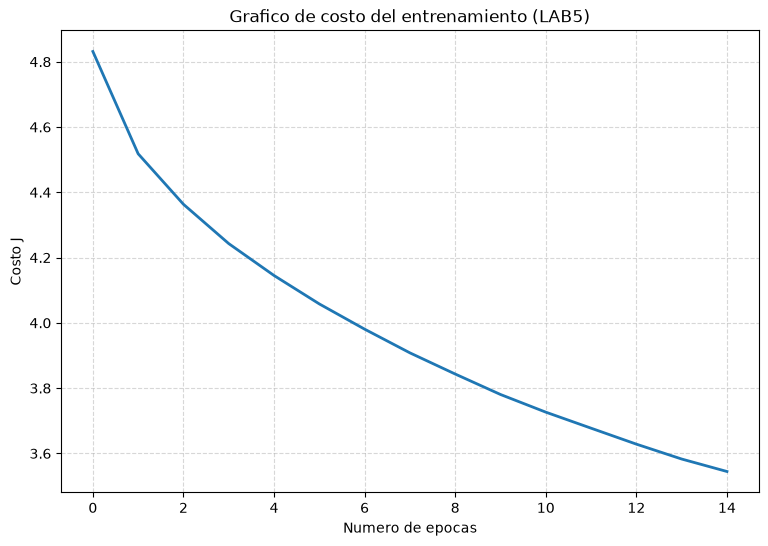

In [8]:
pyplot.figure(figsize=(9, 6))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de epocas')
pyplot.ylabel('Costo J')
pyplot.title('Grafico de costo del entrenamiento (LAB5)')
pyplot.grid(True, linestyle='--', alpha=0.5)
pyplot.savefig('costo.png')
pyplot.show()

## 7. Precisión y métricas

In [9]:
def evaluar(loader, model, nombre):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            preds = model(x_b.to(device))
            preds = torch.argmax(preds, axis=1)
            y_true.extend(y_b.numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    print(f"[{nombre}] Accuracy = {acc:.4f}")
    return y_true, y_pred

y_true_train, y_pred_train = evaluar(train_loader, model, "Entrenamiento")
y_true_test, y_pred_test = evaluar(test_loader, model, "Prueba")

[Entrenamiento] Accuracy = 0.2612
[Prueba] Accuracy = 0.1027


## 8. Guardar los pesos del modelo

In [11]:
PATH = './checkpoint.pt'
torch.save(model.state_dict(), PATH)
print("Pesos guardados en:", PATH)

Pesos guardados en: ./checkpoint.pt


## 9. Cargar el modelo y predecir

In [16]:
model_loaded = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
).to(device)
model_loaded.load_state_dict(torch.load(PATH))
model_loaded.eval()

# Predicción de las primeras 5 muestras de prueba
x_sample = torch.from_numpy(X_test[:50]).to(device)
with torch.no_grad():
    preds = torch.argmax(model_loaded(x_sample), axis=1).cpu().numpy()

print("Predicciones sobre las primeras 5 muestras de prueba:")
for i in range(50):
    print(f"  Real: {y_test[i]} | Predicho: {preds[i]}")

Predicciones sobre las primeras 5 muestras de prueba:
  Real: 55 | Predicho: 71
  Real: 0 | Predicho: 3
  Real: 55 | Predicho: 99
  Real: 171 | Predicho: 74
  Real: 44 | Predicho: 47
  Real: 60 | Predicho: 142
  Real: 45 | Predicho: 25
  Real: 43 | Predicho: 44
  Real: 15 | Predicho: 71
  Real: 29 | Predicho: 78
  Real: 15 | Predicho: 139
  Real: 136 | Predicho: 156
  Real: 19 | Predicho: 66
  Real: 40 | Predicho: 70
  Real: 135 | Predicho: 95
  Real: 199 | Predicho: 199
  Real: 21 | Predicho: 190
  Real: 16 | Predicho: 153
  Real: 147 | Predicho: 65
  Real: 147 | Predicho: 165
  Real: 176 | Predicho: 93
  Real: 175 | Predicho: 95
  Real: 77 | Predicho: 74
  Real: 92 | Predicho: 134
  Real: 123 | Predicho: 137
  Real: 40 | Predicho: 199
  Real: 83 | Predicho: 83
  Real: 153 | Predicho: 64
  Real: 52 | Predicho: 30
  Real: 98 | Predicho: 49
  Real: 50 | Predicho: 100
  Real: 130 | Predicho: 94
  Real: 13 | Predicho: 13
  Real: 25 | Predicho: 25
  Real: 128 | Predicho: 88
  Real: 100 | P